<a href="https://colab.research.google.com/github/MukherjeeDebjani11/-MukherjeeDebjani11github.io/blob/main/Box_CoxAndYeo_Johnson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import PowerTransformer

In [3]:
df=pd.read_csv('Concrete_Data.csv')
df

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [4]:
df.shape

(1030, 9)

In [5]:
df.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [6]:
df.isnull().sum()

,0
Cement (component 1)(kg in a m^3 mixture),0
Blast Furnace Slag (component 2)(kg in a m^3 mixture),0
Fly Ash (component 3)(kg in a m^3 mixture),0
Water (component 4)(kg in a m^3 mixture),0
Superplasticizer (component 5)(kg in a m^3 mixture),0
Coarse Aggregate (component 6)(kg in a m^3 mixture),0
Fine Aggregate (component 7)(kg in a m^3 mixture),0
Age (day),0
"Concrete compressive strength(MPa, megapascals)",0


In [7]:
df.describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [11]:
X = df.drop(columns=['Concrete compressive strength(MPa, megapascals) '])
y = df.iloc[:,-1]

In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [13]:
pt=PowerTransformer(method='box-cox')
X_train_transformed=pt.fit_transform(X_train+0.00001)
X_test_transformed=pt.fit_transform(X_test+0.00001)
pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_})


,cols,box_cox_lambdas
0,Cement (component 1)(kg in a m^3 mixture),0.215602
1,Blast Furnace Slag (component 2)(kg in a m^3 m...,0.028899
2,Fly Ash (component 3)(kg in a m^3 mixture),-0.007561
3,Water (component 4)(kg in a m^3 mixture),0.959062
4,Superplasticizer (component 5)(kg in a m^3 mix...,0.119398
5,Coarse Aggregate (component 6)(kg in a m^3 mi...,1.192491
6,Fine Aggregate (component 7)(kg in a m^3 mixture),1.973781
7,Age (day),-0.014692


In [16]:
#Applying Linear Regression without any transformation
lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)
r2_score(y_test,y_pred)

0.627553179231485

In [18]:
#Cross checking with cross_val_score
lr=LinearRegression()
np.mean(cross_val_score(lr,X,y,scoring='r2'))

np.float64(0.46099404916628606)

In [14]:
#Applying Linear Regression on the transformed data

lr=LinearRegression()
lr.fit(X_train_transformed,y_train)
y_pred2=lr.predict(X_test_transformed)
r2_score(y_test,y_pred2)


0.8061415974066064

In [15]:
#Using Cross_Value_Score for accuracy measurement

In [17]:
pt=PowerTransformer(method='box-cox')
X_transformed=pt.fit_transform(X+0.00001)
lr=LinearRegression()
np.mean(cross_val_score(lr,X_transformed,y,scoring='r2'))

np.float64(0.6668489648058483)

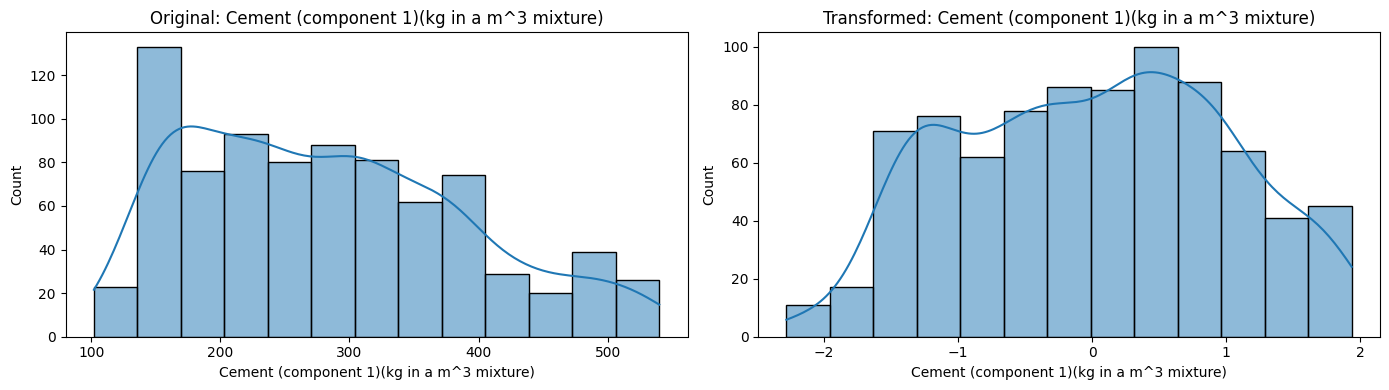

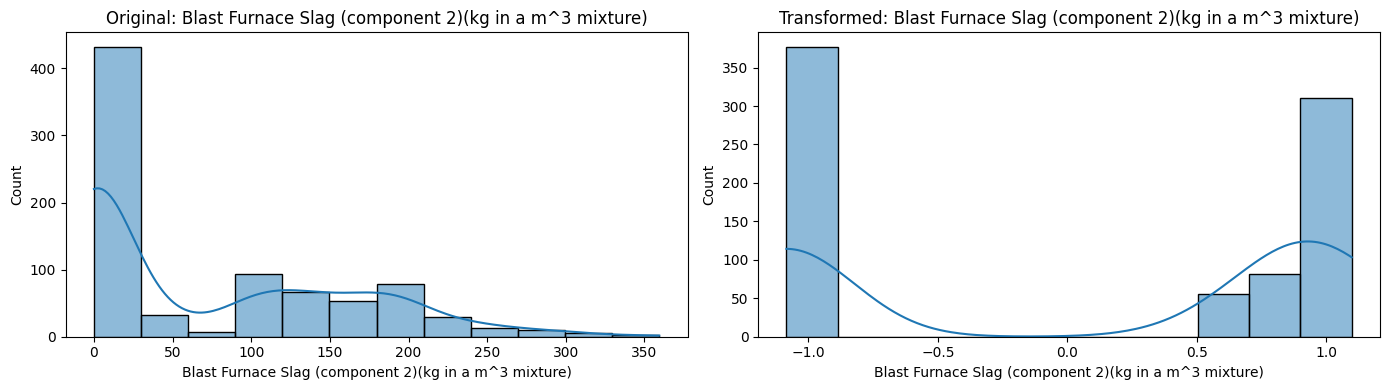

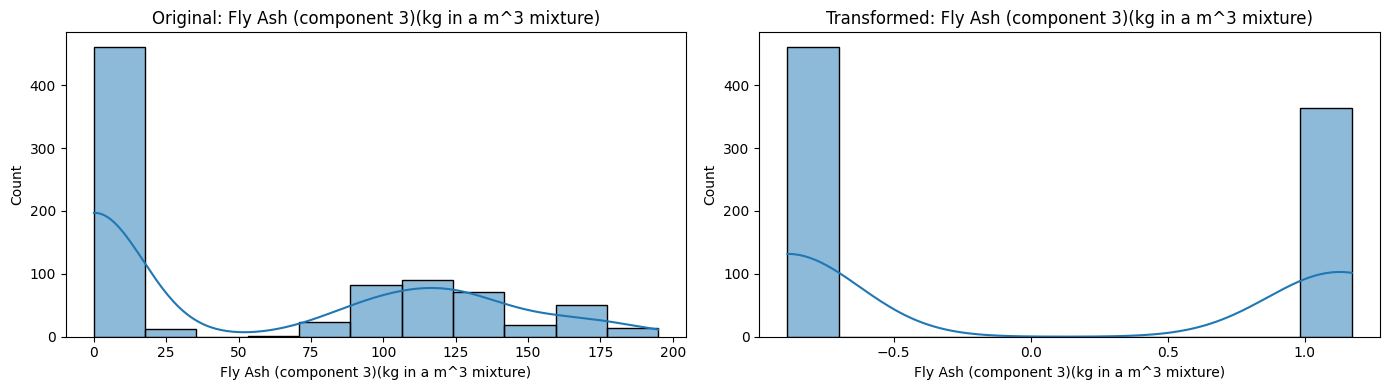

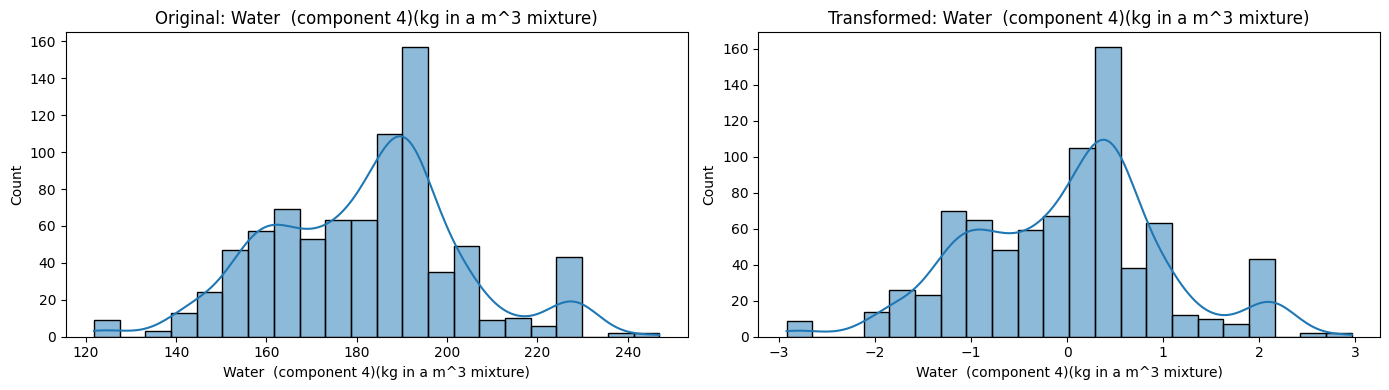

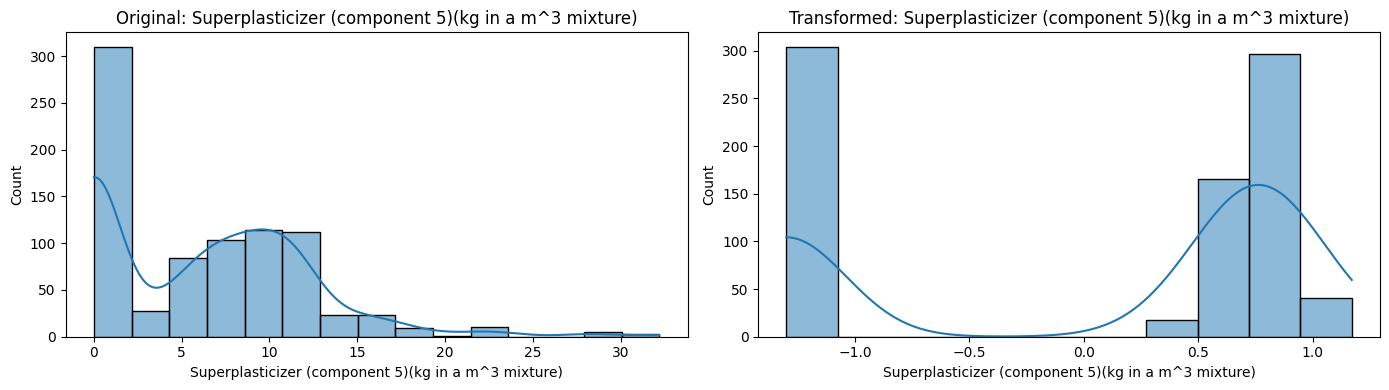

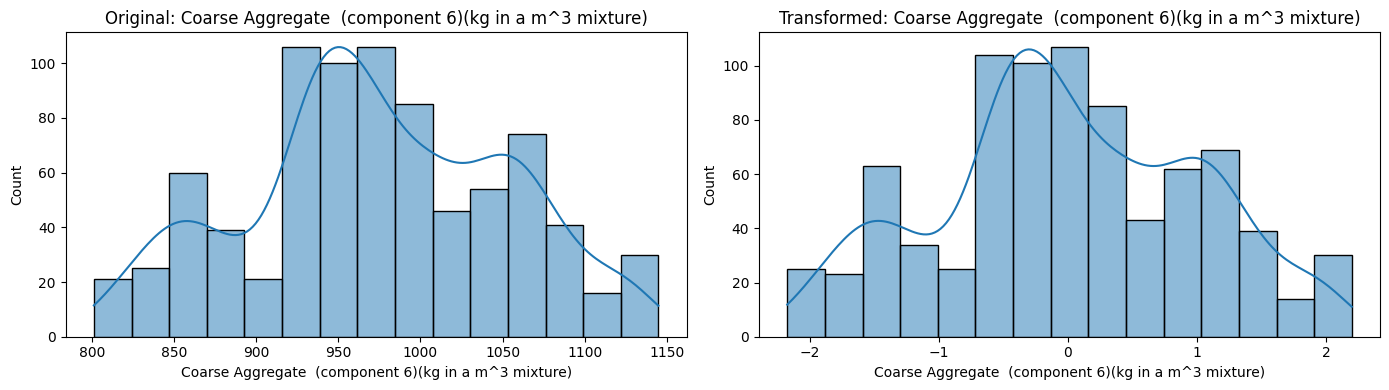

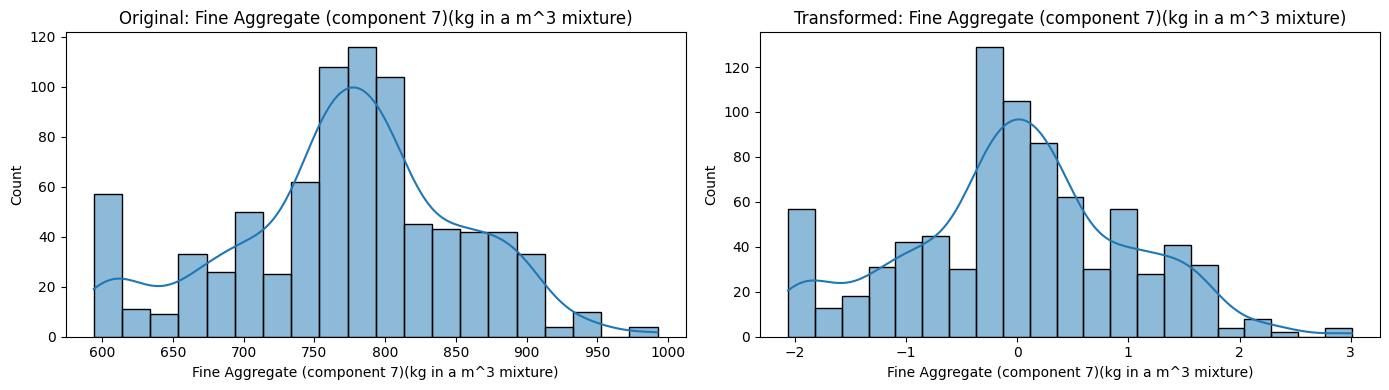

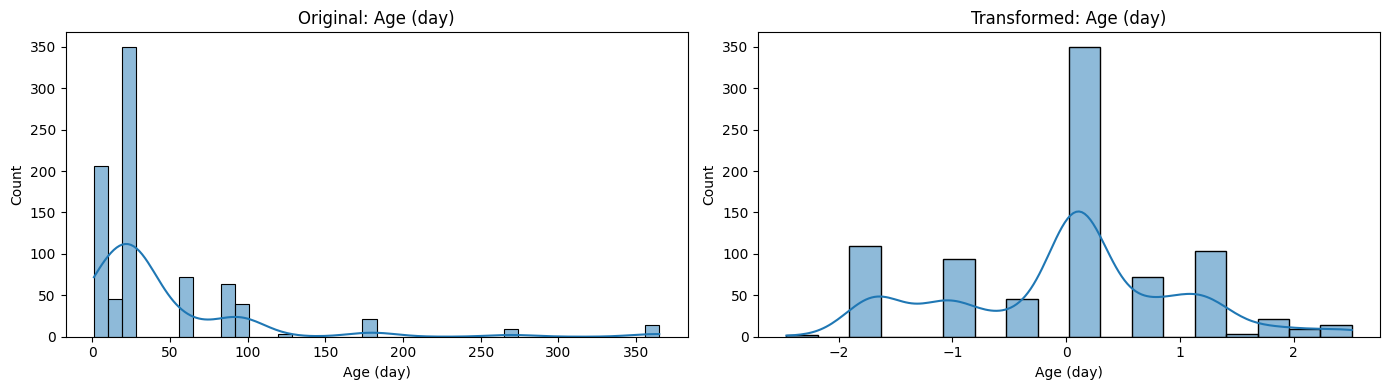

In [20]:
#Before and after comparison for Box-cox Plot
# Convert X_train_transformed to a DataFrame for easier plotting with column names
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=X_train.columns)

for col in X_train_transformed_df.columns:
  plt.figure(figsize=(14,4))

  plt.subplot(121)
  sns.histplot(X_train[col], kde=True)
  plt.title(f'Original: {col}')

  plt.subplot(122)
  sns.histplot(X_train_transformed_df[col], kde=True)
  plt.title(f'Transformed: {col}')
  plt.tight_layout()
  plt.show()

In [21]:
# Applying Yeo-Johnson Transformation

In [23]:
plt1=PowerTransformer()
X_train_transformed2=plt1.fit_transform(X_train)
X_test_transformed2=plt1.fit_transform(X_test)

lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred3=lr.predict(X_test_transformed2)
print(r2_score(y_test,y_pred3))
pd.DataFrame({'cols':X_train.columns,'Yeo_Johnson_lambdas':plt1.lambdas_})


-16.09823696057886


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,cols,Yeo_Johnson_lambdas
0,Cement (component 1)(kg in a m^3 mixture),0.213025
1,Blast Furnace Slag (component 2)(kg in a m^3 m...,0.020476
2,Fly Ash (component 3)(kg in a m^3 mixture),-0.038218
3,Water (component 4)(kg in a m^3 mixture),0.958936
4,Superplasticizer (component 5)(kg in a m^3 mix...,0.304951
5,Coarse Aggregate (component 6)(kg in a m^3 mi...,1.192751
6,Fine Aggregate (component 7)(kg in a m^3 mixture),1.975085
7,Age (day),-0.062443


In [24]:
pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_,'Yeo_Johnson_lambdas':plt1.lambdas_})

,cols,box_cox_lambdas,Yeo_Johnson_lambdas
0,Cement (component 1)(kg in a m^3 mixture),0.172271,0.213025
1,Blast Furnace Slag (component 2)(kg in a m^3 m...,0.028052,0.020476
2,Fly Ash (component 3)(kg in a m^3 mixture),-0.037072,-0.038218
3,Water (component 4)(kg in a m^3 mixture),0.809568,0.958936
4,Superplasticizer (component 5)(kg in a m^3 mix...,0.114979,0.304951
5,Coarse Aggregate (component 6)(kg in a m^3 mi...,1.129168,1.192751
6,Fine Aggregate (component 7)(kg in a m^3 mixture),1.829625,1.975085
7,Age (day),0.048975,-0.062443
